<a href="https://colab.research.google.com/github/Juan-Medinaa/talento_tech/blob/main/RegresionLinealMultiple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#https://rpubs.com/revite19/717614

In [ ]:
import pandas as pd

y =  [78.5, 74.3, 104.3, 87.6, 95.9, 109.2, 102.7, 72.5, 93.1, 115.9, 83.8, 113.3, 109.4]
x1 = [7, 1, 11, 11, 7, 11, 3, 1, 2, 21, 1, 11, 10]
x2 = [26, 29, 56, 31, 52, 55, 71, 31, 54, 47, 40, 66, 68]
x3 = [6, 15, 8, 8, 6, 9, 17, 22, 18, 4, 23, 9, 8]
x4 = [60, 52, 20, 47, 33, 22, 6, 44, 22, 26, 34, 12, 12]

datos = {'y':y,
         'x1':x1,
         'x2':x2,
         'x3':x3,
         'x4':x4}

df = pd.DataFrame(datos)
df

,y,x1,x2,x3,x4
0,78.5,7,26,6,60
1,74.3,1,29,15,52
2,104.3,11,56,8,20
3,87.6,11,31,8,47
4,95.9,7,52,6,33
5,109.2,11,55,9,22
6,102.7,3,71,17,6
7,72.5,1,31,22,44
8,93.1,2,54,18,22
9,115.9,21,47,4,26


In [ ]:
import numpy as np
X = df[['x1', 'x2', 'x3', 'x4']]
X.insert(0, 'intercept', 1)
display(X)

,intercept,x1,x2,x3,x4
0,1,7,26,6,60
1,1,1,29,15,52
2,1,11,56,8,20
3,1,11,31,8,47
4,1,7,52,6,33
5,1,11,55,9,22
6,1,3,71,17,6
7,1,1,31,22,44
8,1,2,54,18,22
9,1,21,47,4,26


In [ ]:
import numpy as np

# Convert X (DataFrame) and y (list) to numpy arrays for matrix operations
X_np = X.to_numpy()
y_np = np.array(df['y'])
print(X_np)
print(y_np)

[[ 1  7 26  6 60]
 [ 1  1 29 15 52]
 [ 1 11 56  8 20]
 [ 1 11 31  8 47]
 [ 1  7 52  6 33]
 [ 1 11 55  9 22]
 [ 1  3 71 17  6]
 [ 1  1 31 22 44]
 [ 1  2 54 18 22]
 [ 1 21 47  4 26]
 [ 1  1 40 23 34]
 [ 1 11 66  9 12]
 [ 1 10 68  8 12]]
[ 78.5  74.3 104.3  87.6  95.9 109.2 102.7  72.5  93.1 115.9  83.8 113.3
 109.4]


In [ ]:
# Calculate X' (transpose of X)
X_transpose = X_np.T
print(X_transpose)

[[ 1  1  1  1  1  1  1  1  1  1  1  1  1]
 [ 7  1 11 11  7 11  3  1  2 21  1 11 10]
 [26 29 56 31 52 55 71 31 54 47 40 66 68]
 [ 6 15  8  8  6  9 17 22 18  4 23  9  8]
 [60 52 20 47 33 22  6 44 22 26 34 12 12]]


In [ ]:
# Calculate X'X
X_transpose_X = X_transpose @ X_np
print(X_transpose_X)

[[   13    97   626   153   390]
 [   97  1139  4922   769  2620]
 [  626  4922 33050  7201 15739]
 [  153   769  7201  2293  4628]
 [  390  2620 15739  4628 15062]]


In [ ]:
# Calculate (X'X)^-1 (inverse of X'X)
X_transpose_X_inv = np.linalg.inv(X_transpose_X)
print(X_transpose_X_inv)

[[ 8.20654575e+02 -8.44180186e+00 -8.45777985e+00 -8.63453878e+00
  -8.28974378e+00]
 [-8.44180186e+00  9.27104019e-02  8.56862094e-02  9.26373566e-02
   8.44549553e-02]
 [-8.45777985e+00  8.56862094e-02  8.75602572e-02  8.78666397e-02
   8.55980995e-02]
 [-8.63453878e+00  9.26373566e-02  8.78666397e-02  9.52014097e-02
   8.63919188e-02]
 [-8.28974378e+00  8.44549553e-02  8.55980995e-02  8.63919188e-02
   8.40311912e-02]]


In [ ]:
# Calculate X'y
X_transpose_y = X_transpose @ y_np
print(X_transpose_y)

[ 1240.5 10032.  62027.8 13981.5 34733.3]


In [ ]:
# Calculate bheta = (X'X)^-1 * X'y and reshape it to a column vector
bheta = (X_transpose_X_inv @ X_transpose_y)

print("Los coeficientes bheta son:")
print(bheta)

Los coeficientes bheta son:
[62.4053693   1.55110265  0.51016758  0.1019094  -0.14406103]


#ERRORES

In [ ]:
df['y_pred'] = X_np @ bheta
df

,y,x1,x2,x3,x4,y_pred
0,78.5,7,26,6,60,78.495240
1,74.3,1,29,15,52,72.788799
2,104.3,11,56,8,20,105.970938
3,87.6,11,31,8,47,89.327100
4,95.9,7,52,6,33,95.649244
5,109.2,11,55,9,22,105.274557
6,102.7,3,71,17,6,104.148669
7,72.5,1,31,22,44,75.674989
8,93.1,2,54,18,22,91.721651
9,115.9,21,47,4,26,115.618452


In [ ]:
df['y-y_pred'] = df['y'] - df['y_pred']
df

,y,x1,x2,x3,x4,y_pred,y-y_pred
0,78.5,7,26,6,60,78.495240,0.004760
1,74.3,1,29,15,52,72.788799,1.511201
2,104.3,11,56,8,20,105.970938,-1.670938
3,87.6,11,31,8,47,89.327100,-1.727100
4,95.9,7,52,6,33,95.649244,0.250756
5,109.2,11,55,9,22,105.274557,3.925443
6,102.7,3,71,17,6,104.148669,-1.448669
7,72.5,1,31,22,44,75.674989,-3.174989
8,93.1,2,54,18,22,91.721651,1.378349
9,115.9,21,47,4,26,115.618452,0.281548


In [ ]:
df['Error_squared']=df['y-y_pred']**2
df

,y,x1,x2,x3,x4,y_pred,y-y_pred,Error_squared
0,78.5,7,26,6,60,78.495240,0.004760,0.000023
1,74.3,1,29,15,52,72.788799,1.511201,2.283728
2,104.3,11,56,8,20,105.970938,-1.670938,2.792032
3,87.6,11,31,8,47,89.327100,-1.727100,2.982875
4,95.9,7,52,6,33,95.649244,0.250756,0.062878
5,109.2,11,55,9,22,105.274557,3.925443,15.409100
6,102.7,3,71,17,6,104.148669,-1.448669,2.098642
7,72.5,1,31,22,44,75.674989,-3.174989,10.080552
8,93.1,2,54,18,22,91.721651,1.378349,1.899847
9,115.9,21,47,4,26,115.618452,0.281548,0.079269


In [ ]:
df['Error_abs']=abs(df['y-y_pred'])
df

,y,x1,x2,x3,x4,y_pred,y-y_pred,Error_squared,Error_abs
0,78.5,7,26,6,60,78.495240,0.004760,0.000023,0.004760
1,74.3,1,29,15,52,72.788799,1.511201,2.283728,1.511201
2,104.3,11,56,8,20,105.970938,-1.670938,2.792032,1.670938
3,87.6,11,31,8,47,89.327100,-1.727100,2.982875,1.727100
4,95.9,7,52,6,33,95.649244,0.250756,0.062878,0.250756
5,109.2,11,55,9,22,105.274557,3.925443,15.409100,3.925443
6,102.7,3,71,17,6,104.148669,-1.448669,2.098642,1.448669
7,72.5,1,31,22,44,75.674989,-3.174989,10.080552,3.174989
8,93.1,2,54,18,22,91.721651,1.378349,1.899847,1.378349
9,115.9,21,47,4,26,115.618452,0.281548,0.079269,0.281548


In [ ]:
n=len(y)
Sr=df['Error_squared'].sum()
print(Sr, Sr/n, (Sr/n)**0.5)

Error_abs=df['Error_abs'].sum()
print(Error_abs, Error_abs/n)

47.86363935049909 3.6818184115768533 1.918806507070698
20.63205892900426 1.5870814560772506


In [ ]:
print(f'Mean Squared Error (MSE): {Sr/n}')
print(f'Root Mean Squared Error (RMSE): {(Sr/n)**0.5}')
print(f'Mean Absolute Error (MAE): {Error_abs/n}')

Mean Squared Error (MSE): 3.6818184115768533
Root Mean Squared Error (RMSE): 1.918806507070698
Mean Absolute Error (MAE): 1.5870814560772506


ERRORES PORCENTUALES, EL MAPE

In [ ]:
df['APE'] = abs((df['y'] - df['y_pred']) / df['y']) * 100
df


,y,x1,x2,x3,x4,y_pred,y-y_pred,Error_squared,Error_abs,APE
0,78.5,7,26,6,60,78.495240,0.004760,0.000023,0.004760,0.006064
1,74.3,1,29,15,52,72.788799,1.511201,2.283728,1.511201,2.033917
2,104.3,11,56,8,20,105.970938,-1.670938,2.792032,1.670938,1.602049
3,87.6,11,31,8,47,89.327100,-1.727100,2.982875,1.727100,1.971576
4,95.9,7,52,6,33,95.649244,0.250756,0.062878,0.250756,0.261476
5,109.2,11,55,9,22,105.274557,3.925443,15.409100,3.925443,3.594728
6,102.7,3,71,17,6,104.148669,-1.448669,2.098642,1.448669,1.410583
7,72.5,1,31,22,44,75.674989,-3.174989,10.080552,3.174989,4.379295
8,93.1,2,54,18,22,91.721651,1.378349,1.899847,1.378349,1.480504
9,115.9,21,47,4,26,115.618452,0.281548,0.079269,0.281548,0.242923


In [ ]:
MAPE = df['APE'].mean()
print(f'Mean Absolute Percentage Error (MAPE): {MAPE:.2f}%')

Mean Absolute Percentage Error (MAPE): 1.72%


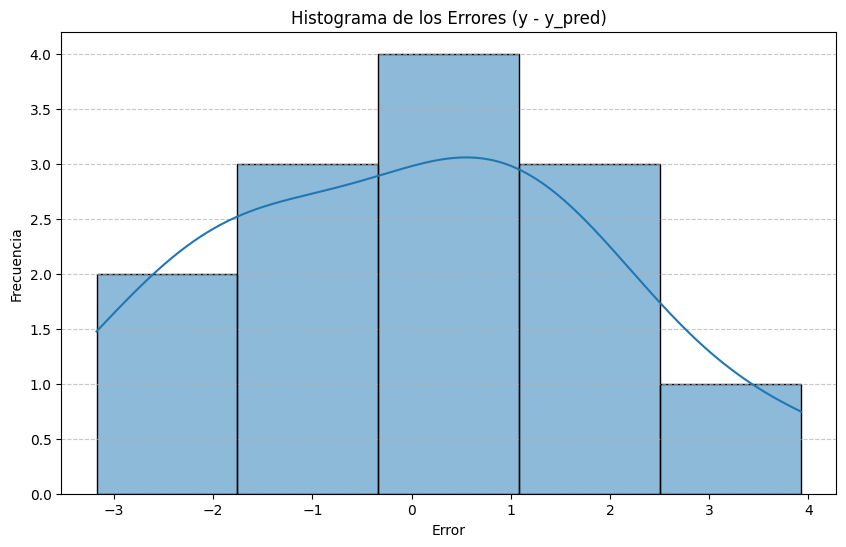

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['y-y_pred'], kde=True, bins=5) # kde=True adds a Kernel Density Estimate plot
plt.title('Histograma de los Errores (y - y_pred)')
plt.xlabel('Error')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()